# 04. 모델 개발 및 평가 — Ridge 회귀

초기 100사이클의 세 지표로 원래 사이클 단위의 `cycle_life`를 예측한다.
**Batch1에서 학습·검증하고 Batch2에서 최종 평가한다. Batch3은 이번 모델링에 사용하지 않는다.**

| 입력 | 생성식 | 담는 정보 |
|---|---|---|
| L: `log10_dqv_var` | log10(var(Q100(V) − Q10(V))) | 초기 전압별 열화 변화 |
| F: `charge_stress` | C1 × s + C2 × (0.8 − s) | 충전속도와 적용 SOC 폭 |
| H: `joule_heat_proxy` | 평균 IR × 1.1² × F | 저항을 반영한 발열 근사 |

s=전환 SOC/100이다. 로그 지표의 직선 경향을 설명하면서 F·H의 일부 중복을 고려해
Ridge를 선택했다. 세 입력을 표준화한 뒤 하나의 회귀식에 함께 넣는다.
후기 knee, 전체 기록 길이, 식별자는 예측 입력에서 제외한다.

In [1]:
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo
import hashlib
import json
import platform
from importlib.metadata import version

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data" / "processed"
OUT = ROOT / "outputs"
OUT.mkdir(exist_ok=True)
SEED = 42
TARGET_MAPE = 9.1
FEATURES = ["log10_dqv_var", "charge_stress", "joule_heat_proxy"]
KEYS = ["batch", "cell_id"]
ALPHAS = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

feature_table = pd.read_csv(DATA / "battery_features.csv")
data = feature_table.loc[feature_table["batch"].isin(["batch1", "batch2"])].copy()
policies = pd.concat([
    pd.read_csv(DATA / f"{batch}_cells.csv").assign(batch=batch)
    for batch in ["batch1", "batch2"]
], ignore_index=True)
assert not data.duplicated(KEYS).any() and not policies.duplicated(KEYS).any()
data = data.merge(policies[KEYS + ["policy"]], on=KEYS, how="left", validate="one_to_one")
# 세 숫자 조건으로 프로토콜을 묶어 표기나 접미사 차이로 그룹이 나뉘는 것을 막는다.
numeric_policy = data["policy"].str.extract(r"^([\d.]+)C\((\d+)%\)-([\d.]+)C")
assert numeric_policy.notna().all().all(), "충전 프로토콜 파싱 실패"
data["protocol"] = numeric_policy.astype(float).astype(str).agg("|".join, axis=1)
data = data.sort_values(KEYS).reset_index(drop=True)
assert set(data["batch"]) == {"batch1", "batch2"}
assert np.isfinite(data[FEATURES + ["cycle_life"]].to_numpy()).all()
assert data["cycle_life"].gt(100).all()

excluded = policies.loc[policies["cycle_life"].notna()].merge(
    data[KEYS], on=KEYS, how="left", indicator=True, validate="one_to_one")
excluded = excluded.loc[excluded["_merge"].eq("left_only"), KEYS + ["policy", "cycle_life"]]
print("모델링 대상:")
display(data.groupby("batch").agg(n_cells=("cell_id", "size"), n_protocols=("protocol", "nunique")))
print("Feature Engineering에서 IR=0으로 제외한 셀:")
display(excluded.reset_index(drop=True))

Matplotlib is building the font cache; this may take a moment.


모델링 대상:


,n_cells,n_protocols
batch,,
batch1,46,23
batch2,33,9


Feature Engineering에서 IR=0으로 제외한 셀:


,batch,cell_id,policy,cycle_life
0,batch2,42,5.6C(26%)-4.5C,442.0
1,batch2,43,5.2C(50%)-4.25C,474.0
2,batch2,44,4.8C(80%)-4.8C-newstructure,1029.0
3,batch2,45,5.2C(58%)-4C-newstructure,841.0
4,batch2,46,5.6C(26%)-4.5C-newstructure,997.0
5,batch2,47,4.8C(80%)-4.8C,503.0


## 1. Batch1 학습·Hold-out 분리

같은 충전 프로토콜을 공유하는 셀은 한쪽에 모은다. `GroupShuffleSplit(test_size=0.2,
random_state=42)`로 **프로토콜의 약 20%**를 Hold-out으로 고정한다.
학습 안의 `GroupKFold(5)`도 같은 원칙을 적용한다.
셀 자체의 중복과 같은 프로토콜의 학습·검증 중복을 모두 검사한다.

Batch2는 배치 간 평가용으로 두고, α 선택은 Batch1 학습 구간의 CV에서만 수행한다.
Hold-out과 Batch2에는 같은 학습 35개 셀로 적합한 모델을 사용한다.

In [2]:
batch1 = data.loc[data["batch"].eq("batch1")].reset_index(drop=True)
test = data.loc[data["batch"].eq("batch2")].reset_index(drop=True)
train_idx, valid_idx = next(GroupShuffleSplit(
    n_splits=1, test_size=0.2, random_state=SEED
).split(batch1, groups=batch1["protocol"]))
train = batch1.iloc[train_idx].reset_index(drop=True)
valid = batch1.iloc[valid_idx].reset_index(drop=True)
assert set(train["cell_id"]).isdisjoint(valid["cell_id"])
assert set(train["protocol"]).isdisjoint(valid["protocol"])
assert len(train) + len(valid) == len(batch1)
assert len(test) > 0 and train["protocol"].nunique() >= 5

cv_splits = list(GroupKFold(n_splits=5).split(train, groups=train["protocol"]))
coverage = np.zeros(len(train), dtype=int)
for fit_idx, check_idx in cv_splits:
    assert set(train.iloc[fit_idx]["protocol"]).isdisjoint(train.iloc[check_idx]["protocol"])
    coverage[check_idx] += 1
assert np.all(coverage == 1)
split_summary = pd.DataFrame([
    {"구분": label, "셀 수": len(frame), "프로토콜 수": frame["protocol"].nunique(),
     "수명 최솟값": frame["cycle_life"].min(), "수명 최댓값": frame["cycle_life"].max()}
    for label, frame in [("Train (Batch1)", train), ("Valid (Batch1 Hold-out)", valid), ("Test (Batch2)", test)]
])
display(split_summary)

train_feature_corr = train[FEATURES].corr()
print("Batch1 학습 데이터의 입력 간 Pearson 상관:")
display(train_feature_corr.round(3))

,구분,셀 수,프로토콜 수,수명 최솟값,수명 최댓값
0,Train (Batch1),35,18,534.0,1227.0
1,Valid (Batch1 Hold-out),11,5,691.0,1190.0
2,Test (Batch2),33,9,392.0,1186.0


Batch1 학습 데이터의 입력 간 Pearson 상관:


,log10_dqv_var,charge_stress,joule_heat_proxy
log10_dqv_var,1.000,0.946,0.842
charge_stress,0.946,1.000,0.928
joule_heat_proxy,0.842,0.928,1.000


## 2. 파이프라인과 α 선택

`StandardScaler → Ridge`를 한 파이프라인에 넣어 매 CV 학습 구간에서만 평균·표준편차를 학습한다.
α 후보는 0.001, 0.01, 0.1, 1, 10, 100이다. 각 구성의 CV 평균 MAPE가 가장 작은 α를 선택한다.
선형회귀는 규제 없는 기준 모델이다. 변수 구성 비교에는 같은 분할과 같은 셀을 사용한다.

**Train (Batch1 CV)**는 선택된 α의 5개 검증 fold MAPE 평균이다.
α 선택에 사용한 점수이며, 별도의 일반화 평가는 고정 Hold-out과 Batch2가 담당한다.
최종 모델 구성은 앞서 정한 **Ridge + L·F·H**로 유지한다.

Batch1 학습 35개에서 L-F r=0.946, F-H r=0.928로 중복이 높았다.
입력을 함께 유지하면서 규제로 계수를 안정시키려는 Ridge의 목적과 연결한다.

In [3]:
feature_sets = {
    "Ridge (L)": FEATURES[:1],
    "Ridge (L+F)": FEATURES[:2],
    "Ridge (L+F+H)": FEATURES,
}
models, searches, comparison_rows = {}, {}, []
for name, columns in feature_sets.items():
    pipeline = Pipeline([("scale", StandardScaler()), ("regressor", Ridge())])
    search = GridSearchCV(
        pipeline, {"regressor__alpha": ALPHAS}, cv=cv_splits,
        scoring="neg_mean_absolute_percentage_error", n_jobs=1, error_score="raise"
    )
    search.fit(train[columns], train["cycle_life"])
    models[name], searches[name] = search.best_estimator_, search
    comparison_rows.append({
        "model": name, "alpha": float(search.best_params_["regressor__alpha"]),
        "Train_CV_MAPE_pct": float(-100 * search.best_score_),
        "CV_std_pp": float(100 * search.cv_results_["std_test_score"][search.best_index_]),
        "Valid_MAPE_pct": float(100 * mean_absolute_percentage_error(
            valid["cycle_life"], search.predict(valid[columns])))
    })

baseline = Pipeline([("scale", StandardScaler()), ("regressor", LinearRegression())])
baseline_scores = -100 * cross_val_score(
    baseline, train[FEATURES], train["cycle_life"], cv=cv_splits,
    scoring="neg_mean_absolute_percentage_error", error_score="raise"
)
baseline.fit(train[FEATURES], train["cycle_life"])
comparison_rows.append({
    "model": "LinearRegression (L+F+H)", "alpha": None,
    "Train_CV_MAPE_pct": float(baseline_scores.mean()), "CV_std_pp": float(baseline_scores.std()),
    "Valid_MAPE_pct": float(100 * mean_absolute_percentage_error(
        valid["cycle_life"], baseline.predict(valid[FEATURES])))
})
comparison = pd.DataFrame(comparison_rows)
display(comparison.round(3))

final_name = "Ridge (L+F+H)"
final_model, final_search = models[final_name], searches[final_name]
best_alpha = float(final_search.best_params_["regressor__alpha"])
scaler = final_model.named_steps["scale"]
assert scaler.n_samples_seen_ == len(train)
assert np.allclose(scaler.mean_, train[FEATURES].mean().to_numpy())
alpha_results = pd.DataFrame({
    "alpha": [float(params["regressor__alpha"]) for params in final_search.cv_results_["params"]],
    "CV_MAPE_pct": -100 * final_search.cv_results_["mean_test_score"],
    "CV_std_pp": 100 * final_search.cv_results_["std_test_score"]
})
print(f"최종 모델: {final_name}, alpha={best_alpha:g}")
display(alpha_results.round(3))

,model,alpha,Train_CV_MAPE_pct,CV_std_pp,Valid_MAPE_pct
0,Ridge (L),1.0,7.509,1.405,11.237
1,Ridge (L+F),1.0,8.309,2.382,9.752
2,Ridge (L+F+H),1.0,8.379,2.408,9.836
3,LinearRegression (L+F+H),NaN,9.534,4.126,10.173


최종 모델: Ridge (L+F+H), alpha=1


,alpha,CV_MAPE_pct,CV_std_pp
0,0.001,9.531,4.120
1,0.010,9.502,4.071
2,0.100,9.250,3.650
3,1.000,8.379,2.408
4,10.000,9.066,2.493
5,100.000,13.426,3.467


## 3. 고정 모델의 평가와 Gap

MAPE(%) = 100 × mean(|실제 수명 − 예측 수명| / 실제 수명).
수명은 로그 변환하지 않는다. 배치 간 비교도 원래 사이클 단위로 수행한다.

- Gap (Train-Valid) = Valid − Train CV
- Gap (Valid-Test) = Test − Valid
- Gap (Target-Test) = Test − 9.1

Gap의 단위는 %p다. 양수는 뒤 평가의 오차가 더 크다는 뜻이다.
Train-Valid는 과적합을 살펴보는 참고값이며, 프로토콜 구성 차이도 함께 반영한다.
[원 논문의 9.1%](https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf)를 과제 비교 기준으로 사용한다.

In [4]:
def regression_metrics(y, prediction):
    y, prediction = np.asarray(y), np.asarray(prediction)
    assert len(y) == len(prediction) and np.isfinite(prediction).all() and (y > 0).all()
    return {
        "MAPE_pct": float(100 * mean_absolute_percentage_error(y, prediction)),
        "MAE_cycles": float(mean_absolute_error(y, prediction)),
        "RMSE_cycles": float(root_mean_squared_error(y, prediction)),
        "bias_cycles": float(np.mean(prediction - y)),
    }

prediction_frames, fold_rows = [], []
# ponytail: 선택한 α의 CV 점수를 보고한다. 별도 검증은 고정 Hold-out으로 확인한다.
for fold, (fit_idx, check_idx) in enumerate(cv_splits, 1):
    fit_data, check_data = train.iloc[fit_idx], train.iloc[check_idx]
    fold_model = clone(final_model).fit(fit_data[FEATURES], fit_data["cycle_life"])
    prediction = fold_model.predict(check_data[FEATURES])
    fold_rows.append({"fold": fold, "n": len(check_data),
                      **regression_metrics(check_data["cycle_life"], prediction)})
    prediction_frames.append(check_data.assign(split="train_cv", fold=fold, predicted_cycle_life=prediction))
fold_metrics = pd.DataFrame(fold_rows)
train_mape = float(fold_metrics["MAPE_pct"].mean())
assert np.isclose(train_mape, -100 * final_search.best_score_)
assert np.allclose(fold_metrics["MAPE_pct"], [
    -100 * final_search.cv_results_[f"split{i}_test_score"][final_search.best_index_] for i in range(5)
])

evaluations = {}
for name, frame in [("valid", valid), ("test", test)]:
    prediction = final_model.predict(frame[FEATURES])
    evaluations[name] = {"n": len(frame), **regression_metrics(frame["cycle_life"], prediction)}
    prediction_frames.append(frame.assign(split=name, fold=0, predicted_cycle_life=prediction))
predictions = pd.concat(prediction_frames, ignore_index=True).sort_values(["split", *KEYS]).reset_index(drop=True)
predictions["error_cycles"] = predictions["predicted_cycle_life"] - predictions["cycle_life"]
predictions["APE_pct"] = 100 * predictions["error_cycles"].abs() / predictions["cycle_life"]
assert not predictions.duplicated(KEYS).any() and len(predictions) == len(data)
assert set(predictions["batch"]) == {"batch1", "batch2"}

valid_mape, test_mape = evaluations["valid"]["MAPE_pct"], evaluations["test"]["MAPE_pct"]
gaps = {"Train-Valid": valid_mape - train_mape, "Valid-Test": test_mape - valid_mape,
        "Target-Test": test_mape - TARGET_MAPE}
performance = pd.DataFrame([
    {"구분": "Train (Batch1 CV)", "MAPE (%)": train_mape, "비고": f"학습 {len(train)}개 셀, 프로토콜 5-fold 평균"},
    {"구분": "Valid (Batch1 Hold-out)", "MAPE (%)": valid_mape, "비고": f"고정 검증 {len(valid)}개 셀"},
    {"구분": "Test (Batch2)", "MAPE (%)": test_mape, "비고": f"배치 간 평가 {len(test)}개 셀"},
    {"구분": "Gap (Train-Valid)", "MAPE (%)": gaps["Train-Valid"], "비고": "Valid − Train CV (%p)"},
    {"구분": "Gap (Valid-Test)", "MAPE (%)": gaps["Valid-Test"], "비고": "Test − Valid (%p)"},
    {"구분": "Gap (Target-Test)", "MAPE (%)": gaps["Target-Test"], "비고": "Test − 9.1 (%p)"},
])
display(performance.round(3))
display(fold_metrics.round(3))
display(pd.DataFrame(evaluations).T.round(3))

,구분,MAPE (%),비고
0,Train (Batch1 CV),8.379,"학습 35개 셀, 프로토콜 5-fold 평균"
1,Valid (Batch1 Hold-out),9.836,고정 검증 11개 셀
2,Test (Batch2),45.029,배치 간 평가 33개 셀
3,Gap (Train-Valid),1.457,Valid − Train CV (%p)
4,Gap (Valid-Test),35.193,Test − Valid (%p)
5,Gap (Target-Test),35.929,Test − 9.1 (%p)


,fold,n,MAPE_pct,MAE_cycles,RMSE_cycles,bias_cycles
0,1,8,12.071,80.539,94.611,-33.709
1,2,8,8.777,71.412,85.576,8.389
2,3,7,4.572,44.831,57.750,-40.443
3,4,6,8.820,74.679,100.761,36.835
4,5,6,7.655,64.826,71.226,4.686


,n,MAPE_pct,MAE_cycles,RMSE_cycles,bias_cycles
valid,11.0,9.836,94.267,117.750,51.566
test,33.0,45.029,215.029,224.872,187.994


## 4. 결과 해석 — 추가 정보와 배치 차이

CV·Hold-out 비교에서 F·H의 추가 정보가 나타나는지 확인한다.
Batch2는 단수명 셀이 많아 Batch1 범위를 벗어난 예측이 생길 수 있다.
예측과 실제 수명을 나란히 보고, 운전 그룹별 오차와 편향을 함께 확인한다.
Base/Newstructure는 정책명에서 구분한 그룹이다.

,dimension,group,n,MAPE_pct,MAE_cycles,RMSE_cycles,bias_cycles
0,variant,Base,27,51.694,231.260,237.149,231.260
1,variant,Newstructure,6,15.037,141.987,158.248,-6.705
2,life_group,other (>=500),7,19.951,158.003,175.182,30.553
3,life_group,short (<500),26,51.781,230.382,236.472,230.382


,feature,standardized_coef,raw_coef
0,log10_dqv_var,-84.041,-287.525
1,charge_stress,-83.388,-268.352
2,joule_heat_proxy,6.791,1099.074


원래 변수 단위의 절편: 667.375


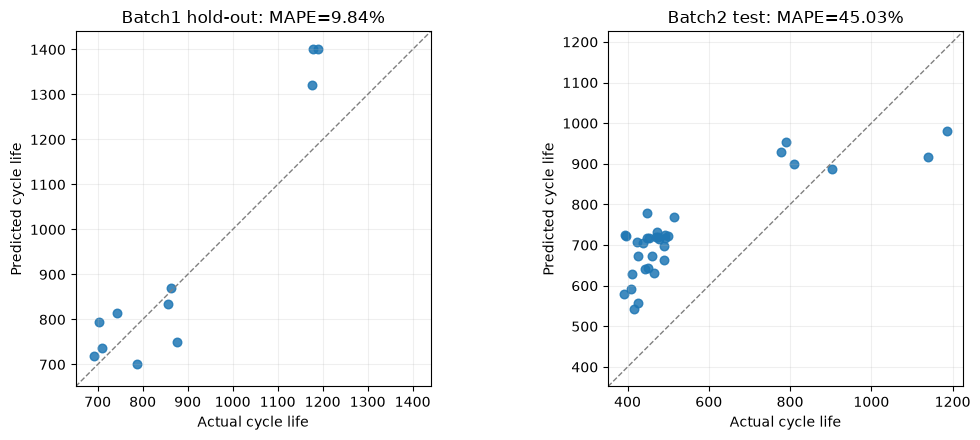

**결과:** 세 변수 Ridge의 Train CV MAPE는 **8.38%**, Batch1 Hold-out은 **9.84%**, Batch2는 **45.03%**다. Batch2와 목표 9.1%의 차이는 **+35.93%p**다. 개별 회귀계수는 다른 입력을 함께 고려한 값이며 열화 원인의 크기로 해석하지 않는다.

In [5]:
test_predictions = predictions.loc[predictions["split"].eq("test")].copy()
test_predictions["variant"] = np.where(
    test_predictions["policy"].str.contains("newstructure", case=False), "Newstructure", "Base")
test_predictions["life_group"] = np.where(test_predictions["cycle_life"].lt(500), "short (<500)", "other (>=500)")
diagnostic_rows = []
for dimension in ["variant", "life_group"]:
    for name, group in test_predictions.groupby(dimension):
        diagnostic_rows.append({"dimension": dimension, "group": name, "n": len(group),
            **regression_metrics(group["cycle_life"], group["predicted_cycle_life"])})
diagnostics = pd.DataFrame(diagnostic_rows)
display(diagnostics.round(3))

regressor = final_model.named_steps["regressor"]
raw_coefficients = regressor.coef_ / scaler.scale_
raw_intercept = float(regressor.intercept_ - raw_coefficients @ scaler.mean_)
coefficients = pd.DataFrame({"feature": FEATURES, "standardized_coef": regressor.coef_,
                             "raw_coef": raw_coefficients})
assert np.allclose(raw_intercept + test[FEATURES].to_numpy() @ raw_coefficients,
                   final_model.predict(test[FEATURES]))
display(coefficients.round(3))
print(f"원래 변수 단위의 절편: {raw_intercept:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, name, title in zip(axes, ["valid", "test"], ["Batch1 hold-out", "Batch2 test"]):
    frame = predictions.loc[predictions["split"].eq(name)]
    ax.scatter(frame["cycle_life"], frame["predicted_cycle_life"], s=38, alpha=0.85)
    limits = [min(frame["cycle_life"].min(), frame["predicted_cycle_life"].min()) - 40,
              max(frame["cycle_life"].max(), frame["predicted_cycle_life"].max()) + 40]
    ax.plot(limits, limits, "--", color="gray", linewidth=1)
    ax.set(xlim=limits, ylim=limits, xlabel="Actual cycle life", ylabel="Predicted cycle life",
           title=f"{title}: MAPE={evaluations[name]['MAPE_pct']:.2f}%")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(OUT / "model_predictions.png", dpi=160, bbox_inches="tight")
plt.show()

display(Markdown(
    f"**결과:** 세 변수 Ridge의 Train CV MAPE는 **{train_mape:.2f}%**, "
    f"Batch1 Hold-out은 **{valid_mape:.2f}%**, Batch2는 **{test_mape:.2f}%**다. "
    f"Batch2와 목표 9.1%의 차이는 **{gaps['Target-Test']:+.2f}%p**다. "
    "개별 회귀계수는 다른 입력을 함께 고려한 값이며 열화 원인의 크기로 해석하지 않는다."
))

## 5. 저장과 재현

모델에는 표준화와 세 변수 Ridge를 함께 저장한다. 성능표·셀별 예측·분할·선택된 α·계수를 남긴다.
Batch1 학습 35개 셀에 적합한 모델을 저장하며, Hold-out을 합쳐 재학습하지 않는다.
실행 종료 시각, 실제 라이브러리 버전, requirements와 입력 파일 SHA-256, 분할 셀을 함께 기록한다.
분할 난수는 42로 고정하며 GroupKFold와 현재 선형 모델 학습은 결정적이다.

간단한 해석 범위: Batch2는 앞선 EDA·피처 검토에 사용됐다. 이번 값은 과제의 배치 간 평가이며
완전히 미관측인 데이터의 성능으로 보지는 않는다. 원 논문과 셀 구성·분할·입력도 달라
9.1%와의 Gap은 참고 비교다.

근거: [Group CV](https://scikit-learn.org/stable/modules/cross_validation.html#group-shuffle-split),
[GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html),
[MAPE](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_percentage_error.html).

In [6]:
performance.to_csv(OUT / "model_performance.csv", index=False)
predictions.to_csv(OUT / "model_predictions.csv", index=False)
joblib.dump(final_model, OUT / "ridge_model.joblib")
manifest = {
    "recorded_at": datetime.now(ZoneInfo("Asia/Seoul")).isoformat(),
    "model": final_name, "features": FEATURES, "target": "cycle_life (raw cycles)",
    "prediction_cycle": 100, "alpha": best_alpha, "alpha_candidates": ALPHAS,
    "seed": SEED, "target_MAPE_pct": TARGET_MAPE,
    "python": platform.python_version(), "scikit_learn": sklearn.__version__,
    "platform": platform.platform(),
    "packages": {package: version(package) for package in
                 ["numpy", "pandas", "matplotlib", "scipy", "scikit-learn", "joblib"]},
    "requirements_sha256": hashlib.sha256((ROOT / "requirements.txt").read_bytes()).hexdigest(),
    "input_file_sha256": {name: hashlib.sha256((DATA / name).read_bytes()).hexdigest()
                          for name in ["battery_features.csv", "batch1_cells.csv", "batch2_cells.csv"]},
    "data_sha256": hashlib.sha256(data.to_csv(index=False).encode()).hexdigest(),
    "train_batch": "batch1", "test_batch": "batch2", "excluded_batches": ["batch3"],
    "cv": "5-fold GroupKFold by numeric charging protocol; selected-alpha CV mean",
    "holdout": "GroupShuffleSplit, test_size=0.2 of protocols, random_state=42",
    "training_rows": train[KEYS + ["policy", "protocol"]].to_dict("records"),
    "validation_rows": valid[KEYS + ["policy", "protocol"]].to_dict("records"),
    "excluded_feature_rows": excluded.to_dict("records"),
    "train_cv_MAPE_pct": train_mape, "train_cv_std_pp": float(fold_metrics["MAPE_pct"].std(ddof=0)),
    "fold_metrics": fold_metrics.to_dict("records"), "evaluations": evaluations,
    "gaps_pp": gaps, "alpha_search": alpha_results.to_dict("records"),
    "comparison": [dict(row) for row in comparison_rows],
    "train_feature_correlations": train_feature_corr.to_dict(),
    "coefficients": coefficients.to_dict("records"), "raw_intercept": raw_intercept,
    "test_diagnostics": diagnostics.to_dict("records"),
    "interpretation_scope": "Batch2 was used in earlier EDA/feature review; assignment cross-batch evaluation."
}
(OUT / "model_metrics.json").write_text(json.dumps(manifest, ensure_ascii=False, indent=2, allow_nan=False) + "\n")

# 저장한 모델과 표가 실행 결과와 일치하는지 확인한다.
restored_model = joblib.load(OUT / "ridge_model.joblib")
assert np.allclose(restored_model.predict(test[FEATURES]), final_model.predict(test[FEATURES]))
pd.testing.assert_frame_equal(pd.read_csv(OUT / "model_performance.csv"), performance)
pd.testing.assert_frame_equal(pd.read_csv(OUT / "model_predictions.csv"), predictions, check_dtype=False)
saved = json.loads((OUT / "model_metrics.json").read_text())
assert saved["features"] == FEATURES and saved["test_batch"] == "batch2"
assert np.isclose(saved["gaps_pp"]["Target-Test"], test_mape - 9.1)
print("저장 및 분할·스케일링·예측 재현 검증 완료")
print("성능표 / 셀별 예측 / 모델·설정 / 예측 그래프:", OUT)

저장 및 분할·스케일링·예측 재현 검증 완료
성능표 / 셀별 예측 / 모델·설정 / 예측 그래프: /Users/u102/workspace_public/021_Data_Analytics_Mini_Projcet/Data_Analytics_MiniProject_Skala/outputs
